# Paper-Only Replication Notebook

Notebook ini sengaja dibuat sebagai versi 'ikut paper' tanpa koreksi metodologis.

Tujuan utamanya adalah melihat bagaimana hasil akan tampak jika kita mengikuti urutan dan asumsi paper secara lebih langsung, termasuk preprocessing sebelum split dan tanpa memprioritaskan leakage prevention.

Catatan penting: notebook ini bukan versi final yang disarankan untuk laporan ilmiah. Ini dibuat hanya untuk perbandingan terhadap versi corrected replication.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

DATA_DIR = Path(".\heart+disease")
FILE_NAMES = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data",
    "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

frames = []
for file_name in FILE_NAMES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(file_path)
    frame = pd.read_csv(file_path, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype(int)
df = df.drop(columns=["target"]).rename(columns={"target_binary": "target"})

print(f"Dataset dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head())

Dataset dimuat: 920 baris x 15 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,processed.cleveland.data,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,processed.cleveland.data,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,processed.cleveland.data,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,processed.cleveland.data,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,processed.cleveland.data,0


## 1. Feature paper dan target

Versi paper-only ini menggunakan 10 fitur yang disebutkan di paper, yaitu: sex, age, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak.

In [2]:
paper_features = [
    "sex", "age", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"
]

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang"]

X = df[paper_features].copy()
y = df["target"].astype(int).copy()

print(f"Jumlah fitur paper: {X.shape[1]}")
print(f"Proporsi target 1: {y.mean():.3f}")
display(X.head())

Jumlah fitur paper: 10
Proporsi target 1: 0.553


,sex,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak
0,1.0,63.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3
1,1.0,67.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5
2,1.0,67.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6
3,1.0,37.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5
4,0.0,41.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4


## 2. Preprocessing paper-like (tanpa koreksi)

Di sini preprocessing diterapkan pada seluruh dataset sebelum split, sesuai pola yang sering terlihat pada replikasi yang hanya mengikuti paper.
Ini berarti ada kemungkinan data leakage, tetapi ini sengaja dipertahankan untuk tujuan perbandingan.

In [3]:
# Preprocessing yang mengikuti pola 'paper-like' dan tidak memisahkan split terlebih dahulu
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_paper_only = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_processed = preprocessor_paper_only.fit_transform(X)
print(f"Shape X setelah preprocessing total: {X_processed.shape}")
print("Catatan: fit dilakukan pada seluruh data sebelum split untuk meniru pola paper-only.")

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True,
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Shape X setelah preprocessing total: (920, 18)
Catatan: fit dilakukan pada seluruh data sebelum split untuk meniru pola paper-only.
Train size: 644
Test size: 276


## 3. Model yang direplikasi

Model yang dipakai mengikuti daftar yang terdapat di paper: Random Forest, Decision Tree, SVM, XGBoost, KNN, Naive Bayes, RBF approximation, LVQ approximation.

In [4]:
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    xgb = None

LVQ_AVAILABLE = False
LVQ_CLASSIFIER = None
try:
    from sklearn_lvq import GlvqModel
    LVQ_AVAILABLE = True
    LVQ_CLASSIFIER = GlvqModel(random_state=42)
except Exception:
    LVQ_CLASSIFIER = None

model_specs = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
        use_label_encoder=False,
    ) if XGB_AVAILABLE else None,
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "RBF (approximation)": SVC(kernel="rbf", random_state=42),
    "LVQ (approximation/conditional)": LVQ_CLASSIFIER,
}

for name, model in model_specs.items():
    if model is None:
        print(f"- {name}: skipped (not available)")
    else:
        print(f"- {name}: {type(model).__name__}")

- Random Forest: RandomForestClassifier
- Decision Tree: DecisionTreeClassifier
- SVM: SVC
- XGBoost: XGBClassifier
- KNN: KNeighborsClassifier
- Naive Bayes: GaussianNB
- RBF (approximation): SVC
- LVQ (approximation/conditional): GlvqModel


In [5]:
results = []

for name, model in model_specs.items():
    if model is None:
        results.append({
            "Model": name,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan,
            "Status": "not_available",
        })
        continue

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Status": "trained",
    })
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

paper_only_df = pd.DataFrame(results)
display(paper_only_df.sort_values("Accuracy", ascending=False))


=== Random Forest ===
Accuracy: 0.8152
Precision: 0.8355
Recall: 0.8301
F1: 0.8328

=== Decision Tree ===
Accuracy: 0.7065
Precision: 0.7338
Recall: 0.7386
F1: 0.7362

=== SVM ===
Accuracy: 0.8152
Precision: 0.8269
Recall: 0.8431
F1: 0.8350

=== XGBoost ===
Accuracy: 0.8007
Precision: 0.8182
Recall: 0.8235
F1: 0.8208

=== KNN ===
Accuracy: 0.8297
Precision: 0.8442
Recall: 0.8497
F1: 0.8469

=== Naive Bayes ===
Accuracy: 0.8333
Precision: 0.8690
Recall: 0.8235
F1: 0.8456

=== RBF (approximation) ===
Accuracy: 0.8152
Precision: 0.8269
Recall: 0.8431
F1: 0.8350


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:15:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== LVQ (approximation/conditional) ===
Accuracy: 0.7609
Precision: 0.7881
Recall: 0.7778
F1: 0.7829


,Model,Accuracy,Precision,Recall,F1,Status
5,Naive Bayes,0.833333,0.868966,0.823529,0.845638,trained
4,KNN,0.829710,0.844156,0.849673,0.846906,trained
0,Random Forest,0.815217,0.835526,0.830065,0.832787,trained
2,SVM,0.815217,0.826923,0.843137,0.834951,trained
6,RBF (approximation),0.815217,0.826923,0.843137,0.834951,trained
3,XGBoost,0.800725,0.818182,0.823529,0.820847,trained
7,LVQ (approximation/conditional),0.760870,0.788079,0.777778,0.782895,trained
1,Decision Tree,0.706522,0.733766,0.738562,0.736156,trained


## 4. Komparasi terhadap nilai paper

Nilai paper yang dipakai di sini adalah angka yang disajikan pada Table 12 paper, dan kita bandingkan dengan hasil paper-only replication.

,Model,Paper Accuracy (%),PaperOnly Accuracy (%),Difference (% point)
0,Random Forest,88.78,81.521739,-7.258261
1,Decision Tree,89.78,70.652174,-19.127826
2,SVM,86.78,81.521739,-5.258261
3,XGBoost,87.78,80.072464,-7.707536
4,KNN,79.78,82.971014,3.191014
5,Naive Bayes,94.78,83.333333,-11.446667
6,RBF (approximation),90.78,81.521739,-9.258261
7,LVQ (approximation/conditional),98.78,76.086957,-22.693043


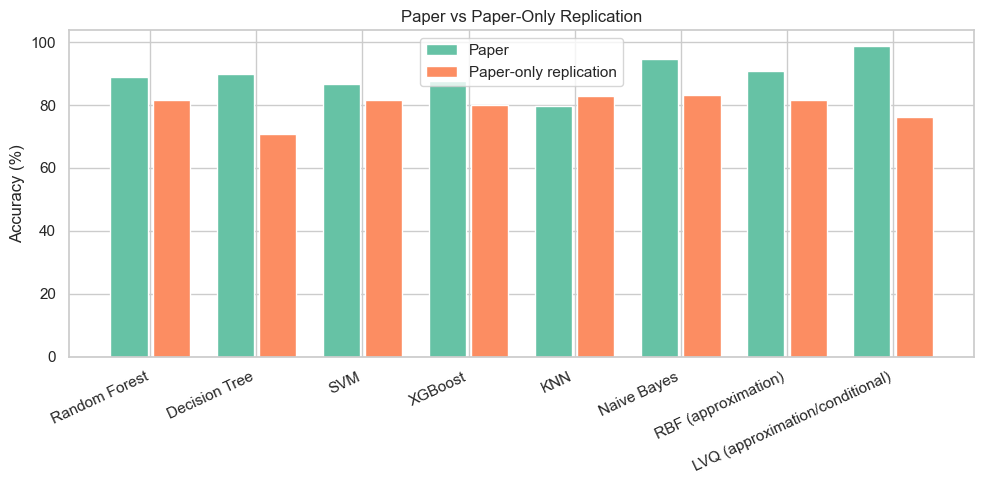

In [6]:
paper_table_12 = {
    "Random Forest": 88.78,
    "Decision Tree": 89.78,
    "SVM": 86.78,
    "XGBoost": 87.78,
    "RBF": 90.78,
    "KNN": 79.78,
    "LVQ": 98.78,
    "Naive Bayes": 94.78,
}

paper_model_order = [
    "Random Forest",
    "Decision Tree",
    "SVM",
    "XGBoost",
    "KNN",
    "Naive Bayes",
    "RBF (approximation)",
    "LVQ (approximation/conditional)",
]

comparison_rows = []
for model_name in paper_model_order:
    result = next((r for r in results if r["Model"] == model_name), None)
    paper_acc = paper_table_12.get("RBF") if model_name == "RBF (approximation)" else \
                paper_table_12.get("LVQ") if model_name == "LVQ (approximation/conditional)" else \
                paper_table_12.get(model_name, np.nan)
    rep_acc = np.nan if result is None else result["Accuracy"] * 100
    diff = np.nan if pd.isna(rep_acc) or pd.isna(paper_acc) else rep_acc - paper_acc
    comparison_rows.append({
        "Model": model_name,
        "Paper Accuracy (%)": paper_acc,
        "PaperOnly Accuracy (%)": rep_acc,
        "Difference (% point)": diff,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

plt.figure(figsize=(10, 5))
positions = np.arange(len(comparison_df))
plt.bar(positions - 0.2, comparison_df["Paper Accuracy (%)"], width=0.35, label="Paper")
plt.bar(positions + 0.2, comparison_df["PaperOnly Accuracy (%)"], width=0.35, label="Paper-only replication")
plt.xticks(positions, comparison_df["Model"], rotation=25, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Paper vs Paper-Only Replication")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpretasi

Notebook ini sengaja tidak melakukan perbaikan metodologis seperti:
- split setelah preprocessing
- fit imputer/scaler hanya pada training set
- pengendalian leakage
- pemilihan fitur dengan pendekatan yang lebih eksplisit

Karena itu, hasilnya bisa lebih tinggi atau lebih rendah dibandingkan versi corrected replication. Ini membantu menunjukkan seberapa besar pengaruh metodologi terhadap hasil.